In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
import pandas as pd

In [2]:
all_data = json.load(open('./raw_data_2.json', 'r'))

In [15]:
data = []
check_double = set()
for entry in all_data:
    unique_key = entry['workerId'] + entry['taskId']
    if unique_key in check_double:
        continue
    check_double.add(unique_key)
    if entry['task'] == 'recognize':
        index = 0
        for item in entry['items']:
            index += 1
            data.append({
                "ab": entry['ab'],
                "index": index,
                "worker": entry['workerId'],
                "file": item['file'],
                "sample": item.get('sample'),
                "success": item['file'] == item['choices'][item['selected']]['file'],
                "time": (item['endTime'] - item['startTime']) / 1000.0
            })
data = pd.DataFrame(data)
groups = sorted(set(data['ab']))
data.shape

(4240, 7)

Text(0.5, 1.0, 'Worker performance')

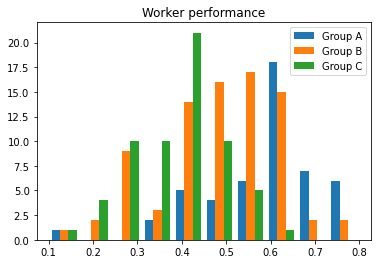

In [17]:
plt.hist([data[data['ab']==group].groupby('worker')['success'].mean() 
         for group in groups])
plt.legend([f'Group {g}' for g in groups])
plt.title('Worker performance')

Text(0.5, 1.0, 'Worker speed vs success rate')

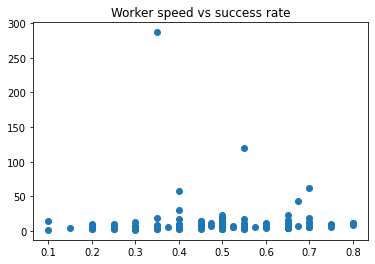

In [8]:
plt.scatter(
    data.groupby('worker')['success'].mean(),
    data.groupby('worker')['time'].mean())
plt.title('Worker speed vs success rate')

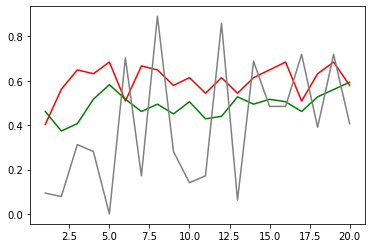

In [21]:
group_colors = {
    "A": "red",
    "B": "green",
    "C": "gray"
}
for g in groups:
    D=data[data['ab']==g].groupby(['index'])['success'].mean()
    plt.plot(D, color=group_colors[g])


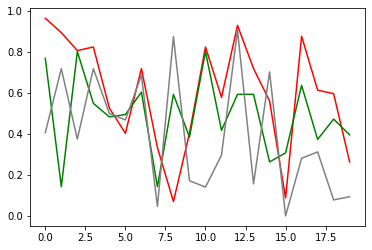

In [23]:
for g in groups:
    D=data[data['ab']==g].groupby(['file'])['success'].mean()
    x=np.linspace(0,D.shape[0]-1,D.shape[0])
    plt.plot(x, D, color=group_colors[g])

In [24]:
data.groupby(['ab','success'])['time'].mean()

ab  success
A   False      10.607513
    True        8.736319
B   False       8.705217
    True        8.721799
C   False      14.018807
    True       11.211553
Name: time, dtype: float64

In [26]:
R = data.groupby(['ab'])['success'].mean()
R

ab
A    0.600000
B    0.491209
C    0.396875
Name: success, dtype: float64

In [27]:
5/(1/R-1)

ab
A    7.500000
B    4.827214
C    3.290155
Name: success, dtype: float64

In [29]:
for ab in groups:
    N = (data['ab']==ab).sum()
    q1 = binom.ppf(0.05, N, R[ab])
    q2 = binom.ppf(0.95, N, R[ab])
    print(f"Group {ab}: {q1/N:.2f} .. {q2/N:.2f}")

Group A: 0.58 .. 0.62
Group B: 0.47 .. 0.51
Group C: 0.37 .. 0.42


In [133]:
print(f"{[1,2]!r}")

[1, 2]
